In [1]:
### set 1
!cp -r /content/drive/MyDrive/TCR-pMHC-results/pmtnet_exp/set1/*.csv '/content/'
!cp -r /content/drive/MyDrive/TCR-pMHC-results/pmtnet_exp/set1/*.zip '/content'

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
#### unzip test
!unzip -q /content/ESM1v_pmtnet_cdr3b.zip -d /content/test_cdr3b
!unzip -q /content/ESM1v_pmtnet_pep.zip   -d /content/test_peptide
!unzip -q /content/ESM1v_pmtnet_mhc.zip   -d /content/test_mhc

In [5]:
import sklearn
import os
from natsort import natsorted

import matplotlib.pyplot as plt
plt.style.use('seaborn')
%matplotlib inline
from sklearn.metrics import *

In [6]:
path_test_cdr3b = '/content/test_cdr3b/content/data_cdr3b/'
path_test_pepti = '/content/test_peptide/content/data_pep/'
path_test_mhc = '/content/test_mhc/content/data_mhc/'

testmat_cdr3b = os.listdir(path_test_cdr3b) 
testmat_pepti = os.listdir(path_test_pepti)
testmat_mhc   = os.listdir(path_test_mhc)

In [7]:
test_nmat_cdr3b = natsorted(testmat_cdr3b)
test_nmat_pepti = natsorted(testmat_pepti)
test_nmat_mhc   = natsorted(testmat_mhc)

In [8]:
print('pmtnet',  len(test_nmat_cdr3b), len(test_nmat_pepti), len(test_nmat_mhc))

pmtnet 6190 6190 6190


In [9]:
import torch
from tqdm import tqdm

In [10]:
test_samples  = len(test_nmat_pepti)
print(test_samples)

6190


In [11]:
test_matmat_cdr3b = np.zeros((test_samples,1280))
test_matmat_pepti = np.zeros((test_samples,1280))
test_matmat_mhc   = np.zeros((test_samples,1280))


for j in tqdm(range(test_samples)):

  test_matmat_cdr3b[j]  = torch.load(path_test_cdr3b+test_nmat_cdr3b[j])['mean_representations'][33]

  test_matmat_pepti[j]  = torch.load(path_test_pepti+test_nmat_pepti[j])['mean_representations'][33]

  test_matmat_mhc[j]    = torch.load(path_test_mhc+test_nmat_mhc[j])['mean_representations'][33]

100%|██████████| 6190/6190 [00:06<00:00, 967.62it/s]


In [12]:
df_test  = pd.read_csv('/content/test6190_set1.csv') #set 1

In [13]:
print('Testing ', test_matmat_cdr3b.shape,  test_matmat_pepti.shape, test_matmat_mhc.shape, df_test.shape)

Testing  (6190, 1280) (6190, 1280) (6190, 1280) (6190, 5)


In [14]:
df_test

,CDR3,Antigen,HLA,long_HLA,label
0,CASSLSFGTEAFF,SMLGIGIYPV,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,1
1,CASSLSFGTEAFF,LMFDRGMSLL,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,1
2,CASSLSFGTEAFF,ILEDRGFNQV,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,1
3,CASSLSFGTEAFF,MMWDRGLGMM,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,1
4,CASSLSFGTEAFF,NLSNLGILPV,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,1
...,...,...,...,...,...
6185,CVSSVDKGGTDTQY,SLFNTVACL,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,0
6186,CVSSVDKGGTDTQY,SLFWTVATL,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,0
6187,CVSSVDKGGTDTQY,SLPNTVATL,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,0
6188,CVSSVDKGGTDTQY,SLYNTIATL,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,0


In [15]:
df_test_pos = df_test[df_test['label'] == 1]

In [16]:
postest_matmat_cdr3b = test_matmat_cdr3b[df_test['label'] == 1]
postest_matmat_pepti = test_matmat_pepti[df_test['label'] == 1]
postest_matmat_mhc   = test_matmat_mhc[df_test['label'] == 1]

In [17]:
postest_matmat_cdr3b.shape, postest_matmat_pepti.shape, postest_matmat_mhc.shape, df_test_pos.shape

((619, 1280), (619, 1280), (619, 1280), (619, 5))

In [18]:
##### hla_list

a_list = ['A*01:01', 'A*02:01', 'A*03:01', 'A*11:01', 'A*24', 'A*24:02']

b_list = ['B*07:02', 'B*08:01', 'B*27', 'B*27:05', 'B*35:01', 'B*35:08', 'B*38:01', 'B*42', 'B*42:01', 'B*44:03', 'B*51:01', 'B*53:01', 'B*57:01', 'B*57:03', 'B*58', 'B*81']

c_list = ['C*05:01', 'C*08:02']

In [19]:
df_test_pos_hlaa = df_test_pos[df_test_pos['HLA'].isin(a_list)]

df_test_pos_hlab = df_test_pos[df_test_pos['HLA'].isin(b_list)]

df_test_pos_hlac = df_test_pos[df_test_pos['HLA'].isin(c_list)]

In [21]:
postest_matmat_pepti_hlaa = postest_matmat_pepti[df_test_pos['HLA'].isin(a_list)]

postest_matmat_pepti_hlab = postest_matmat_pepti[df_test_pos['HLA'].isin(b_list)]

In [22]:
postest_matmat_pepti_hlaa.shape, postest_matmat_pepti_hlab.shape

((366, 1280), (251, 1280))

In [64]:
hla_labels_a = ['HLA-A']*157

In [65]:
hla_labels_b = ['HLA-B']*64

In [66]:
concat_hla = [*hla_labels_a, *hla_labels_b]

In [67]:
len(concat_hla)

221

In [68]:
postest_matmat_pepti_hlaa_unq  = np.unique(postest_matmat_pepti_hlaa, axis=0)
postest_matmat_pepti_hlab_unq  = np.unique(postest_matmat_pepti_hlab, axis=0)

In [69]:
postest_matmat_pepti_hlaa_unq.shape, postest_matmat_pepti_hlab_unq.shape

((157, 1280), (64, 1280))

In [70]:
concat_pepembed = np.concatenate((postest_matmat_pepti_hlaa_unq, postest_matmat_pepti_hlab_unq), axis=0)

In [71]:
concat_pepembed.shape

(221, 1280)

In [51]:
from sklearn.manifold import TSNE

In [81]:
reducer = TSNE(n_components=2, verbose=0, perplexity=10, n_iter=5000, metric='euclidean')
results = reducer.fit_transform(concat_pepembed)

/usr/local/lib/python3.8/dist-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


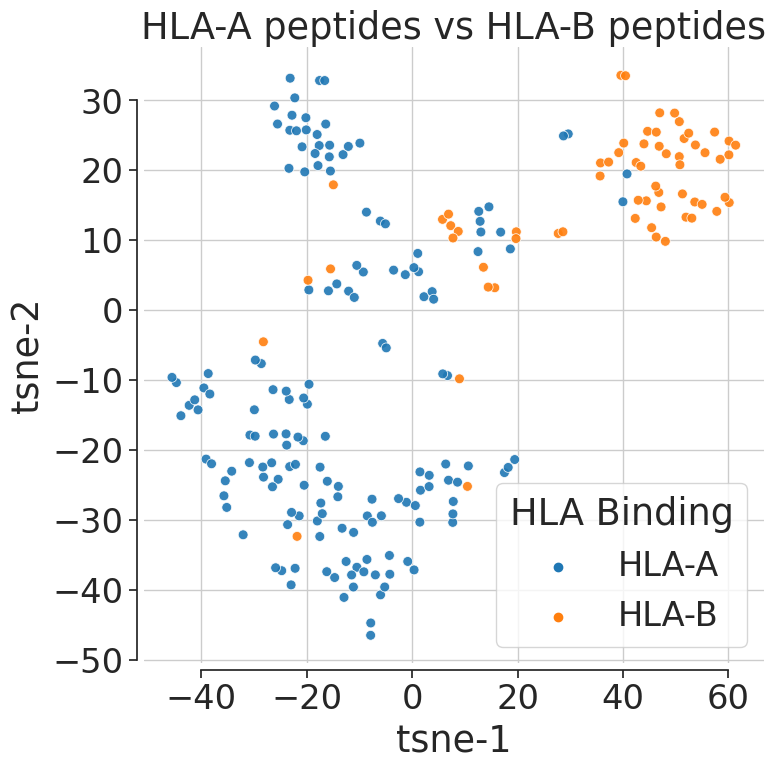

In [83]:
plt.rcParams.update(plt.rcParamsDefault)
sns.set(font_scale=2.2)
sns.set_style("ticks")
df_subset = pd.DataFrame()

df_subset['tsne-1'] = results[:,0]
df_subset['tsne-2'] = results[:,1]
df_subset['Binding']           = concat_hla

plt.figure(figsize=(8,8))
sns.scatterplot(
    x="tsne-1", y="tsne-2",
    hue="Binding",
    palette=sns.color_palette("tab10", 2),
    data=df_subset,
    #legend="full",
    alpha=0.9,
    s=50
)
plt.legend(title = 'HLA Binding')
plt.title('HLA-A peptides vs HLA-B peptides')
plt.grid()
sns.despine(offset=5, trim=True)
plt.show()

In [ ]:
# reducer_umap = umap.UMAP(n_neighbors=5, min_dist=0.001, n_components=2, metric='euclidean')
# results_umap = reducer_umap.fit_transform(concat_pepembed)

In [ ]:
# plt.rcParams.update(plt.rcParamsDefault)
# sns.set(font_scale=1.4)

# df_subset_umap = pd.DataFrame()

# df_subset_umap['umap-1']  = results_umap[:,0]
# df_subset_umap['umap-2']  = results_umap[:,1]
# df_subset_umap['HLA type']= concat_hla

# plt.figure(figsize=(8,8))
# sns.scatterplot(
#     x="umap-1", y="umap-2",
#     hue="HLA type",
#     palette=sns.color_palette("hls", 2),
#     data=df_subset_umap,
#     #legend="full",
#     alpha=0.9,
#     s=20
# )
# #plt.legend(['Negative', 'Positive'], fontsize = 16)
# plt.title('HLA-A peptides vs HLA-B peptides')
# plt.show()

In [ ]:
########## HLA A vs HLA B by PLMs

In [84]:
postest_matmat_mhc_unq, unqidx = np.unique(postest_matmat_mhc, axis=0, return_index=True)

In [85]:
postest_matmat_mhc_unq.shape

(22, 1280)

In [86]:
unqidx

array([556, 555, 274, 280, 152, 180, 397, 270, 456, 561, 402, 437,   0,
       581, 520, 390, 574, 271, 524, 495, 468, 176])

In [87]:
hla_type_list = df_test_pos['HLA'][unqidx].values.tolist()

In [88]:
print(hla_type_list)

['C*08:02', 'C*05:01', 'B*08:01', 'B*42:01', 'B*07:02', 'B*35:08', 'A*11:01', 'B*35:01', 'B*81', 'B*38:01', 'A*03:01', 'B*51:01', 'A*02:01', 'B*27:05', 'B*58', 'A*24', 'A*01:01', 'B*53:01', 'B*27', 'B*57:03', 'B*57:01', 'B*44:03']


In [89]:
hla_type_list_broad = ['HLA-'+item.split('*')[0] for item in hla_type_list ]

In [90]:
reducer_hla = TSNE(n_components=2, verbose=0, perplexity=8, n_iter=5000, metric='euclidean')
results_hla = reducer_hla.fit_transform(postest_matmat_mhc_unq)

/usr/local/lib/python3.8/dist-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


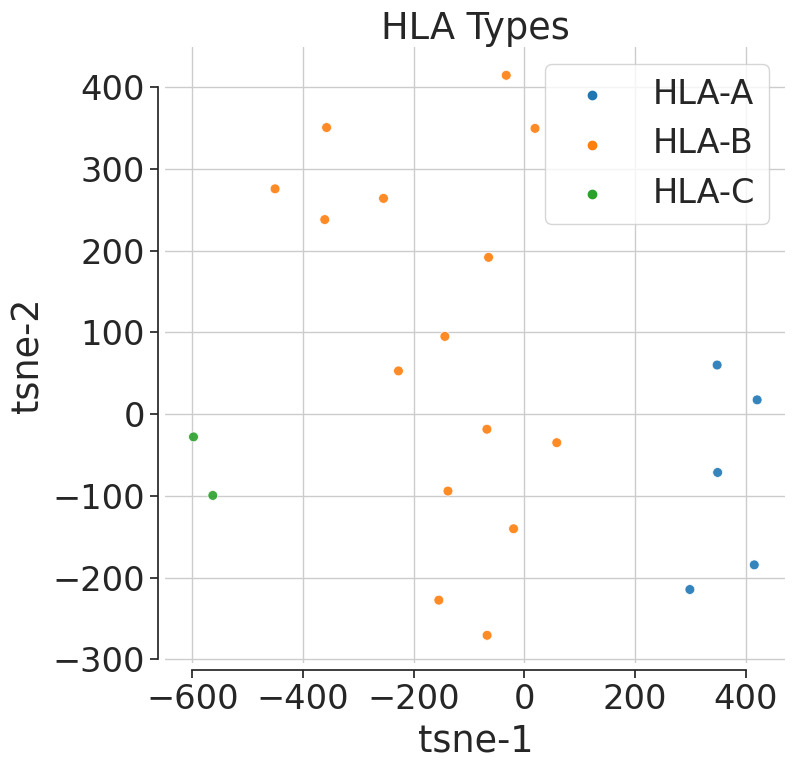

In [93]:
plt.rcParams.update(plt.rcParamsDefault)
sns.set(font_scale=2.2)
sns.set_style("ticks")

df_subset_hla = pd.DataFrame()

df_subset_hla['tsne-1'] = results_hla[:,0]
df_subset_hla['tsne-2'] = results_hla[:,1]
df_subset_hla['HLA Type']           = hla_type_list_broad

plt.figure(figsize=(8,8))
sns.scatterplot(
    x="tsne-1", y="tsne-2",
    hue_order = ['HLA-A', 'HLA-B', 'HLA-C'],
    hue="HLA Type",
    palette=sns.color_palette("tab10", 3),
    data=df_subset_hla,
    #legend="full",
    alpha=0.9,
    s=50
)

sns.despine(offset=5, trim=True)
plt.grid()
plt.legend()
plt.title('HLA Types')
plt.show()

In [ ]:
# reducer_hla = umap.UMAP(n_neighbors=10, min_dist=0.001, n_components=2, metric='euclidean')
# results_hla = reducer_hla.fit_transform(postest_matmat_mhc_unq)

# plt.rcParams.update(plt.rcParamsDefault)
# sns.set(font_scale=1.4)

# df_subset_hla = pd.DataFrame()

# df_subset_hla['tsne-1'] = results_hla[:,0]
# df_subset_hla['tsne-2'] = results_hla[:,1]
# df_subset_hla['HLA Type']           = hla_type_list_broad

# plt.figure(figsize=(8,8))
# sns.scatterplot(
#     x="tsne-1", y="tsne-2",
#     hue_order = ['HLA-A', 'HLA-B', 'HLA-C'],
#     hue="HLA Type",
#     palette=sns.color_palette("hls", 3)[::-1],
#     data=df_subset_hla,
#     legend="full",
#     alpha=0.9,
#     s=50
# )
# #plt.legend(['Negative', 'Positive'], fontsize = 16)
# plt.title('HLA Types')
# plt.show()